In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

import sys
sys.path.append("../")
from src.generative_models import get_pt_utility

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
%load_ext autoreload
%autoreload 2

RNG = np.random.default_rng(2024)
np.set_printoptions(suppress=True)

In [5]:
FONTSIZE_1 = 30
FONTSIZE_2 = 24
FONTSIZE_2 = 20

In [6]:
ev_diff = np.arange(-9, 9+1, 3)
num_trials = np.array([100] * len(ev_diff))
ev_diff

array([-9, -6, -3,  0,  3,  6,  9])

## New Lotteries

In [7]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
gamble_df = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between range
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 2:
                    # check if absolute var_diff is between range
                    if np.abs(var_a - var_b) <= 10 and np.abs(var_a - var_b) >= 2:
                        # check if absolute skew_diff is between range
                        if np.abs(skew_a - skew_b) <= 1.5 and np.abs(skew_a - skew_b) >= 0.4:
                            # check for loss and var confound
                            if loss_a < loss_b and var_a < var_b:
                                # check if both evs are positive
                                if ev_a > 0 and ev_b > 0:
                                    if i > 1 and i < 5:
                                        if utility_la[0] < utility_la[1] and utility_ra[0] > utility_ra[1]:
                                            gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                            gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                                            counter += 1
                                            if counter == num_trials[i]:
                                                break
                                    else:
                                        gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                        gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                                        counter += 1
                                        print(counter)
                                        if counter == num_trials[i]:
                                            break

In [ ]:
# gamble_df.to_csv("../data/new_approach/lotteries_new_100.csv", index=False)

## Old Lotteries

In [ ]:
ev_diff = np.arange(-9, 9+1, 3)
num_trials = np.array([100] * len(ev_diff))
ev_diff

In [ ]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
gamble_df = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between range
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 2:
                    # check if absolute var_diff is between range
                    if np.abs(var_a - var_b) <= 10 and np.abs(var_a - var_b) >= 2:
                        # check if absolute skew_diff is between range
                        if np.abs(skew_a - skew_b) <= 1.5 and np.abs(skew_a - skew_b) >= 0.4:
                            # check for loss and var confound
                            if loss_a < loss_b and var_a > var_b:
                                # check if both evs are positive
                                if ev_a > 0 and ev_b > 0:
                                    if i > 1 and i < 5:
                                        if utility_la[0] < utility_la[1] and utility_ra[0] < utility_ra[1]:
                                            gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                            gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                                            counter += 1
                                            if counter == num_trials[i]:
                                                break
                                    else:
                                        gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                        gamble_df = pd.concat([gamble_df, pd.DataFrame(gamble)], ignore_index=True)
                                        counter += 1
                                        print(counter)
                                        if counter == num_trials[i]:
                                            break

In [ ]:
# gamble_df.to_csv("../data/new_approach/lotteries_old_100.csv", index=False)

## Nearest Neighbors

In [8]:
new_lotteries_colltection = pd.read_csv("../data/new_approach/lotteries_new_100.csv")
old_lotteries_colltection = pd.read_csv("../data/new_approach/lotteries_old_100.csv")

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

features = ['loss_diff', 'var_diff', 'skew_diff']
scaled_features = [f + '_scaled' for f in features]

# Apply hard constraints
def apply_constraints(df):
    df = df[np.abs(df['skew_diff']) <= 1]
    df = df[np.abs(df['loss_diff']) <= 10]
    df = df[np.abs(df['var_diff']) <= 8]
    return df.reset_index(drop=True)

df_new = apply_constraints(new_lotteries_colltection.copy())
df_old = apply_constraints(old_lotteries_colltection.copy())

# Tag source
df_new['source'] = 'new'
df_old['source'] = 'old'
combined = pd.concat([df_new, df_old], ignore_index=True)

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(combined[features])
for i, f in enumerate(features):
    combined[scaled_features[i]] = scaled_data[:, i]

# Split back
df_new = combined[combined['source'] == 'new'].drop(columns='source').reset_index(drop=True)
df_old = combined[combined['source'] == 'old'].drop(columns='source').reset_index(drop=True)

# EV bins
ev_bins = sorted(combined['ev_diff'].unique())
n_per_bin = 12  # or less, if needed

sampled_new, sampled_old = [], []

for ev in ev_bins:
    bin_new = df_new[df_new['ev_diff'] == ev]
    bin_old = df_old[df_old['ev_diff'] == ev]

    n_available = min(len(bin_new), len(bin_old), n_per_bin)
    if n_available < n_per_bin:
        print(f"⚠️ Skipping bin {ev} due to insufficient data.")
        continue

    sampled_new.append(bin_new.sample(n=n_per_bin, random_state=42))
    sampled_old.append(bin_old.sample(n=n_per_bin, random_state=42))

# Combine across bins
pooled_new = pd.concat(sampled_new).reset_index(drop=True)
pooled_old = pd.concat(sampled_old).reset_index(drop=True)

# Global matching
dist_matrix = cdist(pooled_new[scaled_features], pooled_old[scaled_features], metric='euclidean')
row_ind, col_ind = linear_sum_assignment(dist_matrix)

matched_new = pooled_new.iloc[row_ind].reset_index(drop=True)
matched_old = pooled_old.iloc[col_ind].reset_index(drop=True)

# Drop scaled features and label
matched_new = matched_new.drop(columns=scaled_features)
matched_old = matched_old.drop(columns=scaled_features)
matched_new['lottery_type'] = 'new'
matched_old['lottery_type'] = 'old'


In [10]:
lotteries_new = matched_new
lotteries_old = matched_old

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from scipy.spatial.distance import cdist
# from scipy.optimize import linear_sum_assignment


# features = ['loss_diff', 'var_diff', 'skew_diff']
# scaled_features = [f + '_scaled' for f in features]

# # Apply original-scale constraint BEFORE scaling
# df1 = new_lotteries_colltection.copy()
# df2 = old_lotteries_colltection.copy()
# df1 = df1[np.abs(df1['skew_diff']) <= 1].reset_index(drop=True)  # << HARD CONSTRAINT
# df2 = df2[np.abs(df2['skew_diff']) <= 1].reset_index(drop=True)  # << HARD CONSTRAINT
# df1 = df1[np.abs(df1['loss_diff']) <= 10].reset_index(drop=True)  # << HARD CONSTRAINT
# df2 = df2[np.abs(df2['loss_diff']) <= 10].reset_index(drop=True)  # << HARD CONSTRAINT
# df1 = df1[np.abs(df1['var_diff']) <= 8].reset_index(drop=True)  # << HARD CONSTRAINT
# df2 = df2[np.abs(df2['var_diff']) <= 8].reset_index(drop=True)  # << HARD CONSTRAINT

# # Tag for splitting later
# df1['source'] = 'new'
# df2['source'] = 'old'
# combined = pd.concat([df1, df2], ignore_index=True)

# # Standardize all relevant features
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(combined[features])
# for i, f in enumerate(features):
#     combined[scaled_features[i]] = scaled_data[:, i]

# # Split back
# df1_scaled = combined[combined['source'] == 'new'].drop(columns='source').reset_index(drop=True)
# df2_scaled = combined[combined['source'] == 'old'].drop(columns='source').reset_index(drop=True)

# # Unique ev_diff bins
# ev_bins = sorted(combined['ev_diff'].unique())

# # Final storage
# lotteries_new, lotteries_old = [], []

# # === Per-bin matching ===
# for ev in ev_bins:
#     bin_df1 = df1_scaled[df1_scaled['ev_diff'] == ev].reset_index(drop=True)
#     bin_df2 = df2_scaled[df2_scaled['ev_diff'] == ev].reset_index(drop=True)

#     n = min(len(bin_df1), len(bin_df2), 12)
#     if n < 12:
#         print(f"⚠️ Skipping ev_diff = {ev} due to insufficient data (after applying skew_diff constraint on df1).")
#         continue

#     bin_df1 = bin_df1.iloc[:n].copy()
#     bin_df2 = bin_df2.iloc[:n].copy()

#     dist_matrix = cdist(bin_df1[scaled_features], bin_df2[scaled_features], metric='euclidean')
#     row_ind, col_ind = linear_sum_assignment(dist_matrix)

#     matched_1 = bin_df1.iloc[row_ind].reset_index(drop=True)
#     matched_2 = bin_df2.iloc[col_ind].reset_index(drop=True)

#     lotteries_new.append(matched_1)
#     lotteries_old.append(matched_2)

# # Combine final results
# lotteries_new = pd.concat(lotteries_new).reset_index(drop=True)
# lotteries_old = pd.concat(lotteries_old).reset_index(drop=True)

# lotteries_new = lotteries_new.drop(columns=scaled_features)
# lotteries_old = lotteries_old.drop(columns=scaled_features)

# # Optional: label sources
# lotteries_new['lottery_type'] = 'new'
# lotteries_old['lottery_type'] = 'old'


In [ ]:
# lotteries_new.to_csv("../data/new_approach/lotteries_new.csv", index=False)
# lotteries_old.to_csv("../data/new_approach/lotteries_old.csv", index=False)

In [11]:
FONTSIZE_1 = 30
FONTSIZE_2 = 26
FONTSIZE_3 = 20

In [15]:
lotteries_new['mean_ev'] = lotteries_new[['ev_a', 'ev_b']].mean(axis=1)
lotteries_old['mean_ev'] = lotteries_old[['ev_a', 'ev_b']].mean(axis=1)

In [17]:
lotteries_new

,outcome_a1,outcome_a2,outcome_a3,outcome_b1,outcome_b2,outcome_b3,ev_a,ev_b,ev_diff,var_a,var_b,var_diff,loss_a,loss_b,loss_diff,skew_a,skew_b,skew_diff,lottery_type,mean_ev
0,32,18,-17,54,19,-13,11.000000,20.000000,-9.0,20.607442,27.361774,-6.754332,-17,-13,-4,-0.47,0.05,-0.52,new,15.500000
1,42,33,-51,71,21,-41,8.000000,17.000000,-9.0,41.880783,45.811207,-3.930424,-51,-41,-10,-0.68,-0.13,-0.55,new,12.500000
2,72,17,-75,98,8,-65,4.666667,13.666667,-9.0,60.642852,66.665000,-6.022148,-75,-65,-10,-0.30,0.13,-0.43,new,9.166667
3,57,22,-52,85,14,-45,9.000000,18.000000,-9.0,45.438603,53.147593,-7.708990,-52,-45,-7,-0.41,0.11,-0.52,new,13.500000
4,37,15,-44,59,10,-34,2.666667,11.666667,-9.0,34.198765,37.985377,-3.786612,-44,-34,-10,-0.49,0.07,-0.56,new,7.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,74,52,-49,90,6,-46,25.666667,16.666667,9.0,53.555786,56.031737,-2.475951,-49,-46,-3,-0.62,0.28,-0.90,new,21.166667
80,80,52,-3,88,15,-1,43.000000,34.000000,9.0,34.477046,38.738439,-4.261394,-3,-1,-2,-0.37,0.62,-0.99,new,38.500000
81,85,43,-14,93,1,-7,38.000000,29.000000,9.0,40.570926,45.372532,-4.801607,-14,-7,-7,-0.18,0.69,-0.87,new,33.500000
82,89,52,-12,98,6,-2,43.000000,34.000000,9.0,41.721298,45.372532,-3.651235,-12,-2,-10,-0.31,0.69,-1.00,new,38.500000


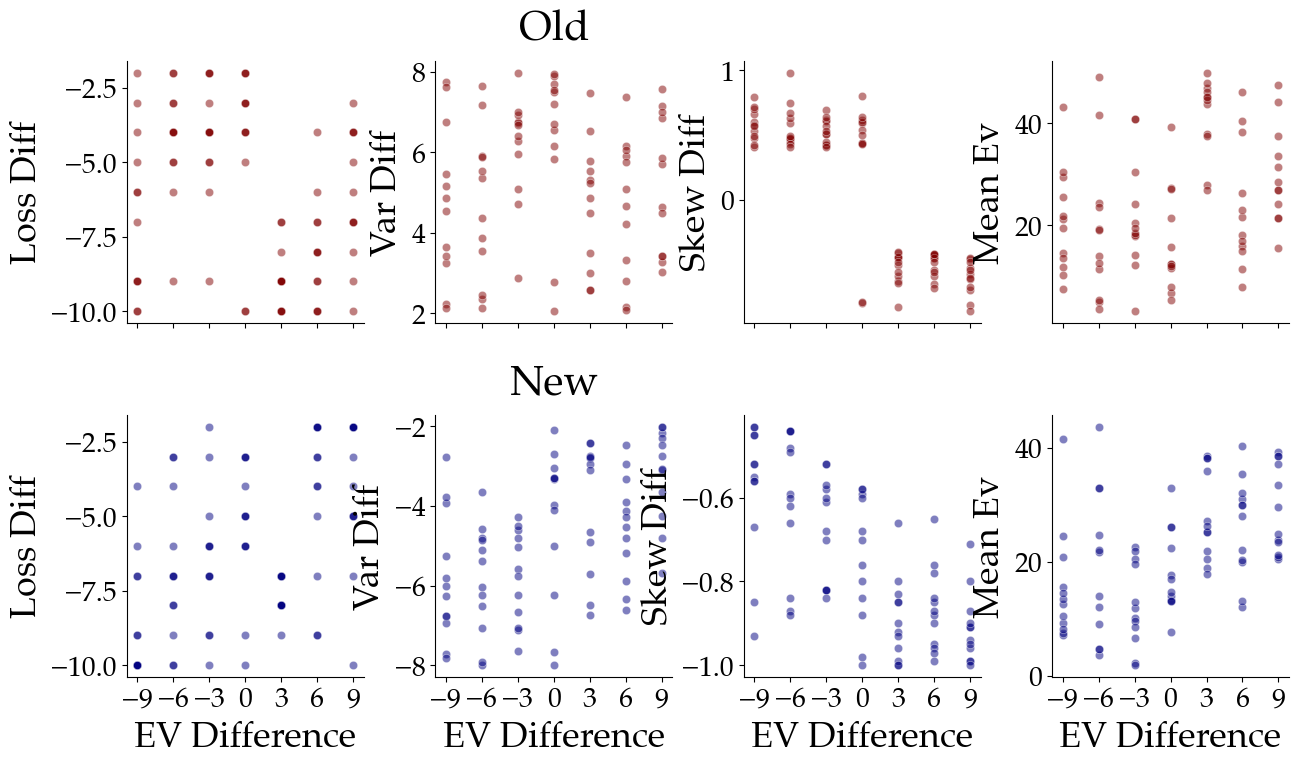

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8), sharex=True, gridspec_kw={'hspace': 0.35, 'wspace': 0.3})

features = ['loss_diff', 'var_diff', 'skew_diff', 'mean_ev']

for col, feat in enumerate(features):
    # Top row: Old
    sns.scatterplot(
        data=lotteries_old,
        x='ev_diff',
        y=lotteries_old[feat],
        color='maroon',
        alpha=0.5,
        ax=axes[0, col],
    )
    axes[0, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[0, col].set_xlabel('')
    if col == 1:
        axes[0, col].set_title('Old', fontsize=FONTSIZE_1, pad=15)
    else:
        axes[0, col].set_title('')
    axes[0, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[0, col].set_xticks(ev_diff)
    sns.despine(ax=axes[0, col])

    # Bottom row: New
    sns.scatterplot(
        data=lotteries_new,
        x='ev_diff',
        y=lotteries_new[feat],
        color='navy',
        alpha=0.5,
        ax=axes[1, col],
    )
    axes[1, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[1, col].set_xlabel('EV Difference', fontsize=FONTSIZE_2)
    if col == 1:
        axes[1, col].set_title('New', fontsize=FONTSIZE_1, pad=15)
    else:
        axes[1, col].set_title('')
    axes[1, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[1, col].set_xticks(ev_diff)
    sns.despine(ax=axes[1, col])

# plt.savefig(
#     f'../plots/lottery_characteristics.pdf',
#     transparent=True, dpi=600,
#     bbox_inches='tight'
# )


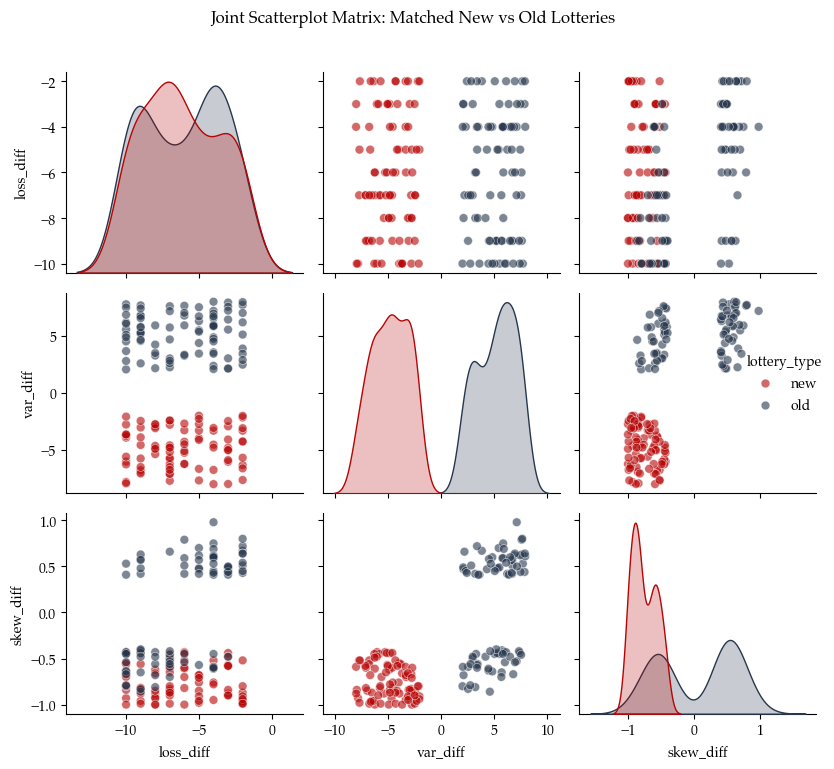

In [207]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine matched datasets
matched_all = pd.concat([matched_new, matched_old], ignore_index=True)

# Select features and add lottery_type as hue
features = ['loss_diff', 'var_diff', 'skew_diff']
sns.pairplot(
    matched_all,
    vars=features,
    hue='lottery_type',
    palette={'new': '#B70404', 'old': '#27374D'},
    plot_kws={'alpha': 0.6, 's': 40},
    diag_kind='kde'
)

plt.suptitle("Joint Scatterplot Matrix: Matched New vs Old Lotteries", y=1.02)
plt.tight_layout()
plt.show()



## Final preparation

In [196]:
lotteries_new['sanity_check'] = False
lotteries_old['sanity_check'] = False

In [151]:
context_new = lotteries_new[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

context_old = lotteries_old[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

In [152]:
rows_as_tuples = [tuple(row) for row in context_new]
all_unique = len(rows_as_tuples) == len(set(rows_as_tuples))
print("All rows are unique:", all_unique)

All rows are unique: True


In [153]:
rows_as_tuples = [tuple(row) for row in context_old]
all_unique = len(rows_as_tuples) == len(set(rows_as_tuples))
print("All rows are unique:", all_unique)

All rows are unique: True


In [154]:
lotteries_new_df1 = lotteries_new.groupby('ev_diff', group_keys=False).head(6)
lotteries_new_df2 = lotteries_new.groupby('ev_diff', group_keys=False).tail(6)

In [155]:
new_row = pd.DataFrame({
    'outcome_a1': [45], 'outcome_a2': [12], 'outcome_a3': [-30],
    'outcome_b1': [50], 'outcome_b2': [15], 'outcome_b3': [-25],
    'ev_a': [9.0], 'ev_b': [13.33], 'ev_diff': [4.33],
    'var_a': [916.0], 'var_b': [902.22], 'var_diff': [-13.78], 
    'loss_a': [30], 'loss_b': [25], 'loss_diff': [-5],
    'skew_a': [0.2], 'skew_b': [0.3], 'skew_diff': [0.1],
    'lottery_type': ['new'], 'sanity_check': ['true']
})
lotteries_new_df1 = pd.concat([lotteries_new_df1, new_row], ignore_index=True)

In [156]:
new_row = pd.DataFrame({
    'outcome_a1': [60], 'outcome_a2': [33], 'outcome_a3': [-12],
    'outcome_b1': [66], 'outcome_b2': [40], 'outcome_b3': [-5],
    'ev_a': [27.0], 'ev_b': [33.67], 'ev_diff': [6.67],
    'var_a': [868.67], 'var_b': [822.89], 'var_diff': [-45.78], 
    'loss_a': [12], 'loss_b': [5], 'loss_diff': [-7],
    'skew_a': [-0.1], 'skew_b': [0.1], 'skew_diff': [0.2],
    'lottery_type': ['new'], 'sanity_check': ['true']
})
lotteries_new_df2 = pd.concat([lotteries_new_df2, new_row], ignore_index=True)

In [157]:
lotteries_old_df1 = lotteries_old.groupby('ev_diff', group_keys=False).head(6)
lotteries_old_df2 = lotteries_old.groupby('ev_diff', group_keys=False).tail(6)

In [158]:
new_row = pd.DataFrame({
    'outcome_a1': [39], 'outcome_a2': [22], 'outcome_a3': [-40],
    'outcome_b1': [47], 'outcome_b2': [30], 'outcome_b3': [-33],
    'ev_a': [7.0], 'ev_b': [14.67], 'ev_diff': [7.67],
    'var_a': [1044.67], 'var_b': [1036.22], 'var_diff': [-8.45], 
    'loss_a': [40], 'loss_b': [33], 'loss_diff': [-7],
    'skew_a': [0.05], 'skew_b': [0.1], 'skew_diff': [0.05],
    'lottery_type': ['old'], 'sanity_check': ['true']
})
lotteries_old_df1 = pd.concat([lotteries_old_df1, new_row], ignore_index=True)

In [159]:
new_row = pd.DataFrame({
    'outcome_a1': [65], 'outcome_a2': [50], 'outcome_a3': [-10],
    'outcome_b1': [72], 'outcome_b2': [55], 'outcome_b3': [-4],
    'ev_a': [35.0], 'ev_b': [41.0], 'ev_diff': [6.0],
    'var_a': [900.0], 'var_b': [860.0], 'var_diff': [-40.0], 
    'loss_a': [10], 'loss_b': [4], 'loss_diff': [-6],
    'skew_a': [-0.2], 'skew_b': [0.05], 'skew_diff': [0.25],
    'lottery_type': ['old'], 'sanity_check': ['true']
})
lotteries_old_df2 = pd.concat([lotteries_old_df2, new_row], ignore_index=True)

In [160]:
lotteries_new_df1.to_csv("../data/new_approach/lotteries_new_df1.csv", index=False)
lotteries_new_df2.to_csv("../data/new_approach/lotteries_new_df2.csv", index=False)
lotteries_old_df1.to_csv("../data/new_approach/lotteries_old_df1.csv", index=False)
lotteries_old_df2.to_csv("../data/new_approach/lotteries_old_df2.csv", index=False)

## Old lottery inspection

In [145]:
old_lottery_new = pd.read_csv('/Users/lschumacher/Desktop/pt_experiment_backup/condition_files/lotteries_new.csv')
old_lottery_old = pd.read_csv('/Users/lschumacher/Desktop/pt_experiment_backup/condition_files/lotteries_old.csv')

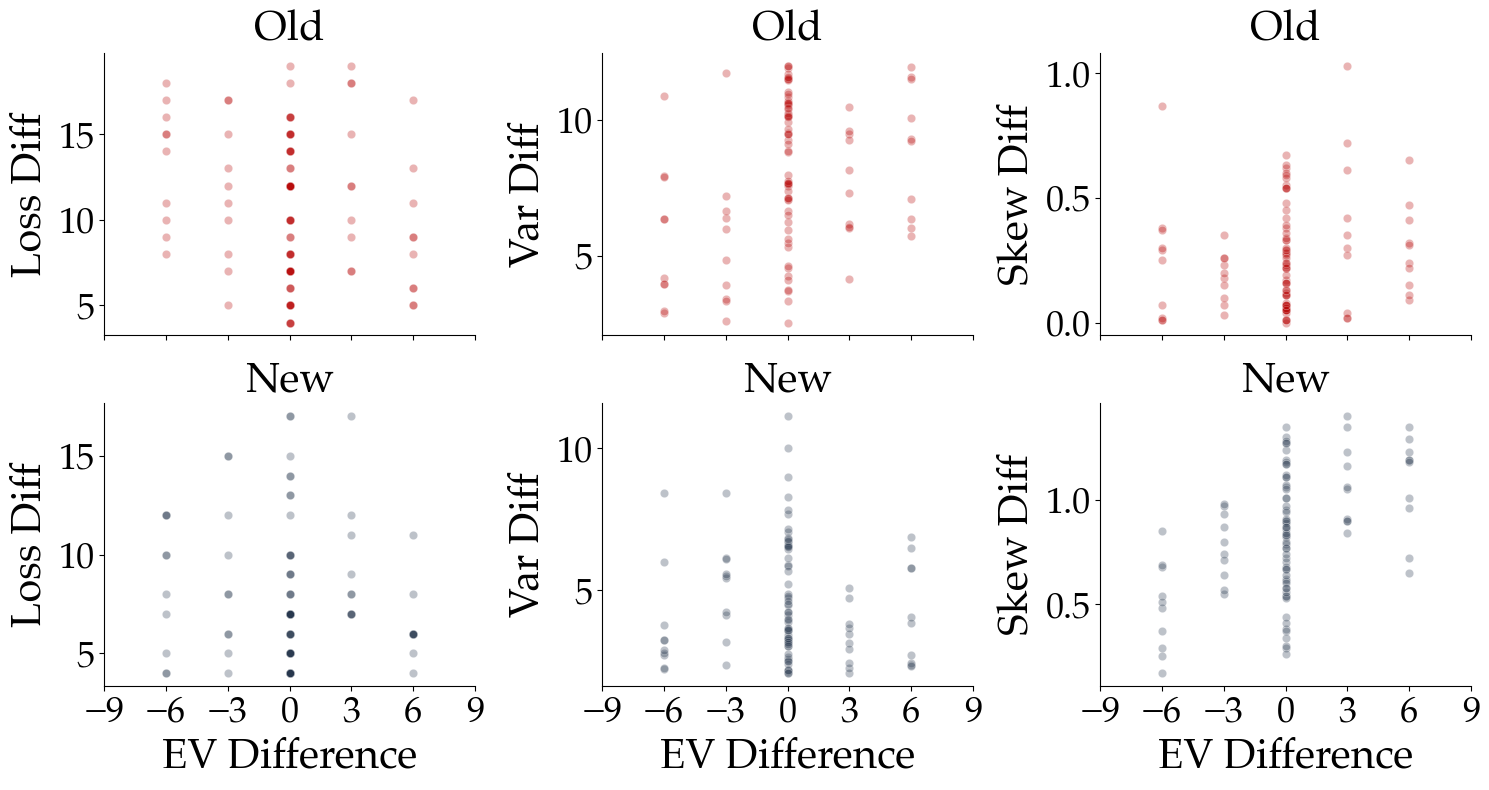

In [187]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
features = ['loss_diff', 'var_diff', 'skew_diff']
colors = ['maroon', 'darkgreen', 'navy']
for col, feat in enumerate(features):
    # Top row: Old
    sns.scatterplot(
        data=old_lottery_old,
        x='ev_diff',
        y=np.abs(old_lottery_old[feat]),
        color='#B70404',
        alpha=0.3,
        ax=axes[0, col],
    )
    axes[0, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_1)
    axes[0, col].set_xlabel('')
    axes[0, col].set_title('Old', fontsize=FONTSIZE_1)
    axes[0, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
    axes[0, col].set_xticks(ev_diff)
    sns.despine(ax=axes[0, col])
    # Bottom row: New
    sns.scatterplot(
        data=old_lottery_new,
        x='ev_diff',
        y=np.abs(old_lottery_new[feat]),
        color='#27374D',
        alpha=0.3,
        ax=axes[1, col],
    )
    axes[1, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_1)
    axes[1, col].set_xlabel('EV Difference', fontsize=FONTSIZE_1)
    axes[1, col].set_title('New', fontsize=FONTSIZE_1)
    axes[1, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_2)
    axes[1, col].set_xticks(ev_diff)
    sns.despine(ax=axes[1, col])
plt.tight_layout()
plt.show()